In [13]:
from pathlib import Path
import types
import dill


# ============================================================
# LOCALISATION AUTOMATIQUE DU PROJET
# ============================================================

CURRENT_DIR = Path.cwd().resolve()

candidats = [
    CURRENT_DIR,
    CURRENT_DIR / "Script_intermediaire",
    Path.home() / "Downloads" / "Projet 4" / "Script_intermediaire",
]

# Ajout des dossiers parents et de leurs éventuels sous-dossiers
for parent in CURRENT_DIR.parents:
    candidats.append(parent)

    candidats.append(parent / "Script_intermediaire")


SCRIPT_DIR = next(
    (
        chemin
        for chemin in candidats
        if chemin.is_dir()
        and chemin.name == "Script_intermediaire"
    ),
    None,
)


if SCRIPT_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser le dossier 'Script_intermediaire'.\n"
        f"Dossier courant détecté : {CURRENT_DIR}"
    )


SESSION_DIR = SCRIPT_DIR / "outputs"
SESSION_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# OBJETS TECHNIQUES À NE PAS SAUVEGARDER
# ============================================================

NOMS_TECHNIQUES = {
    "In",
    "Out",
    "exit",
    "quit",
    "get_ipython",
    "open",
    "CURRENT_DIR",
    "SCRIPT_DIR",
    "SESSION_DIR",
    "NOMS_TECHNIQUES",
    "candidats",
    "parent",
    "chemin",
    "sauvegarder_session",
    "charger_session",
    "objets_restaures",
}


# ============================================================
# SAUVEGARDE AUTOMATIQUE
# ============================================================

def sauvegarder_session(etape):
    """
    Sauvegarde automatiquement tous les objets utilisateur
    sérialisables présents dans le notebook.

    Les modules, objets internes de Jupyter/VS Code et objets
    non sérialisables sont ignorés.
    """

    chemin_final = SESSION_DIR / f"session_etape{etape}.pkl"
    chemin_temporaire = SESSION_DIR / f"session_etape{etape}.tmp"

    objets_serialises = {}
    objets_ignores = {}

    for nom, objet in list(globals().items()):

        # Objets internes ou privés
        if nom.startswith("_"):
            continue

        # Infrastructure de sauvegarde
        if nom in NOMS_TECHNIQUES:
            continue

        # Objets techniques injectés par Data Wrangler
        if "DW_OUTPUT_FORMATTER" in nom:
            continue

        # Les modules seront réimportés normalement
        if isinstance(objet, types.ModuleType):
            continue

        try:
            # Chaque objet est sérialisé séparément.
            # Un objet défectueux ne bloque donc pas tous les autres.
            objets_serialises[nom] = dill.dumps(
                objet,
                recurse=True
            )

        except Exception as erreur:
            objets_ignores[nom] = (
                f"{type(erreur).__name__}: {erreur}"
            )

    contenu_session = {
        "version": 1,
        "etape": etape,
        "objets": objets_serialises,
    }

    # Écriture atomique : on écrit d'abord dans un fichier temporaire
    with open(chemin_temporaire, "wb") as fichier:
        dill.dump(contenu_session, fichier)

    chemin_temporaire.replace(chemin_final)

    print("=" * 65)
    print(f"Session de l'étape {etape} enregistrée")
    print(f"Fichier : {chemin_final}")
    print(f"Objets sauvegardés : {len(objets_serialises)}")
    print(f"Objets ignorés : {len(objets_ignores)}")

    if objets_ignores:
        print("\nObjets non sérialisables ignorés :")

        for nom, erreur in objets_ignores.items():
            print(f" - {nom} → {erreur}")

    print("=" * 65)

    return chemin_final


# ============================================================
# CHARGEMENT AUTOMATIQUE
# ============================================================

def charger_session(etape):
    """
    Recharge automatiquement tous les objets enregistrés
    à l'étape demandée, avec leurs noms d'origine.
    """

    chemin_session = SESSION_DIR / f"session_etape{etape}.pkl"

    if not chemin_session.exists():
        raise FileNotFoundError(
            f"Session introuvable : {chemin_session}\n"
            f"Exécute d'abord entièrement le notebook de l'étape {etape}."
        )

    with open(chemin_session, "rb") as fichier:
        contenu_session = dill.load(fichier)

    objets_serialises = contenu_session["objets"]

    objets_restaures = {}
    objets_non_restaures = {}

    for nom, objet_serialise in objets_serialises.items():

        try:
            objets_restaures[nom] = dill.loads(
                objet_serialise
            )

        except Exception as erreur:
            objets_non_restaures[nom] = (
                f"{type(erreur).__name__}: {erreur}"
            )

    globals().update(objets_restaures)

    print("=" * 65)
    print(f"Session de l'étape {etape} chargée")
    print(f"Fichier : {chemin_session}")
    print(f"Objets restaurés : {len(objets_restaures)}")
    print(f"Objets non restaurés : {len(objets_non_restaures)}")

    if objets_non_restaures:
        print("\nObjets impossibles à restaurer :")

        for nom, erreur in objets_non_restaures.items():
            print(f" - {nom} → {erreur}")

    print("=" * 65)

    return objets_restaures


print("Infrastructure de session initialisée")
print("Dossier des notebooks :", SCRIPT_DIR)
print("Dossier des sessions :", SESSION_DIR)

Infrastructure de session initialisée
Dossier des notebooks : /Users/thibaultdautheville/Downloads/Projet 4/Script_intermediaire
Dossier des sessions : /Users/thibaultdautheville/Downloads/Projet 4/Script_intermediaire/outputs


In [14]:
objets_restaures = charger_session(1)

Session de l'étape 1 chargée
Fichier : /Users/thibaultdautheville/Downloads/Projet 4/Script_intermediaire/outputs/session_etape1.pkl
Objets restaurés : 59
Objets non restaurés : 0


In [15]:
#Librairy


from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# Etape 2 : préparation de la donnée pour la modélisation

In [16]:
DataFrameRH.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   note_evaluation_actuelle                   1470 non-null   int64
 7   heure_supplementaires                      1470 non-null   str  
 8   augementation_salaire_precedente           1470 non-null   str  
 9   age                                        1470 non-null   int64
 10  genre                                      1470 non-null   

Paires chiffrées Pearson :
age <-> revenu_mensuel : 0.50
age <-> annee_experience_totale : 0.68
age <-> annees_dans_l_entreprise : 0.31
age <-> annees_dans_le_poste_actuel : 0.21
age <-> annees_depuis_la_derniere_promotion : 0.22
age <-> annes_sous_responsable_actuel : 0.20
age <-> distance_domicile_travail : -0.00
age <-> nombre_employee_sous_responsabilite : nan
age <-> niveau_hierarchique_poste : 0.51
age <-> nombre_experiences_precedentes : 0.30
age <-> nb_formations_suivies : -0.02
age <-> nombre_participation_pee : 0.04
age <-> satisfaction_employee_environnement : 0.01
age <-> satisfaction_employee_nature_travail : -0.00
age <-> satisfaction_employee_equipe : 0.05
age <-> satisfaction_employee_equilibre_pro_perso : -0.02
age <-> note_evaluation_precedente : 0.03
age <-> note_evaluation_actuelle : 0.00
age <-> niveau_education : 0.21
revenu_mensuel <-> annee_experience_totale : 0.77
revenu_mensuel <-> annees_dans_l_entreprise : 0.51
revenu_mensuel <-> annees_dans_le_poste_actuel 

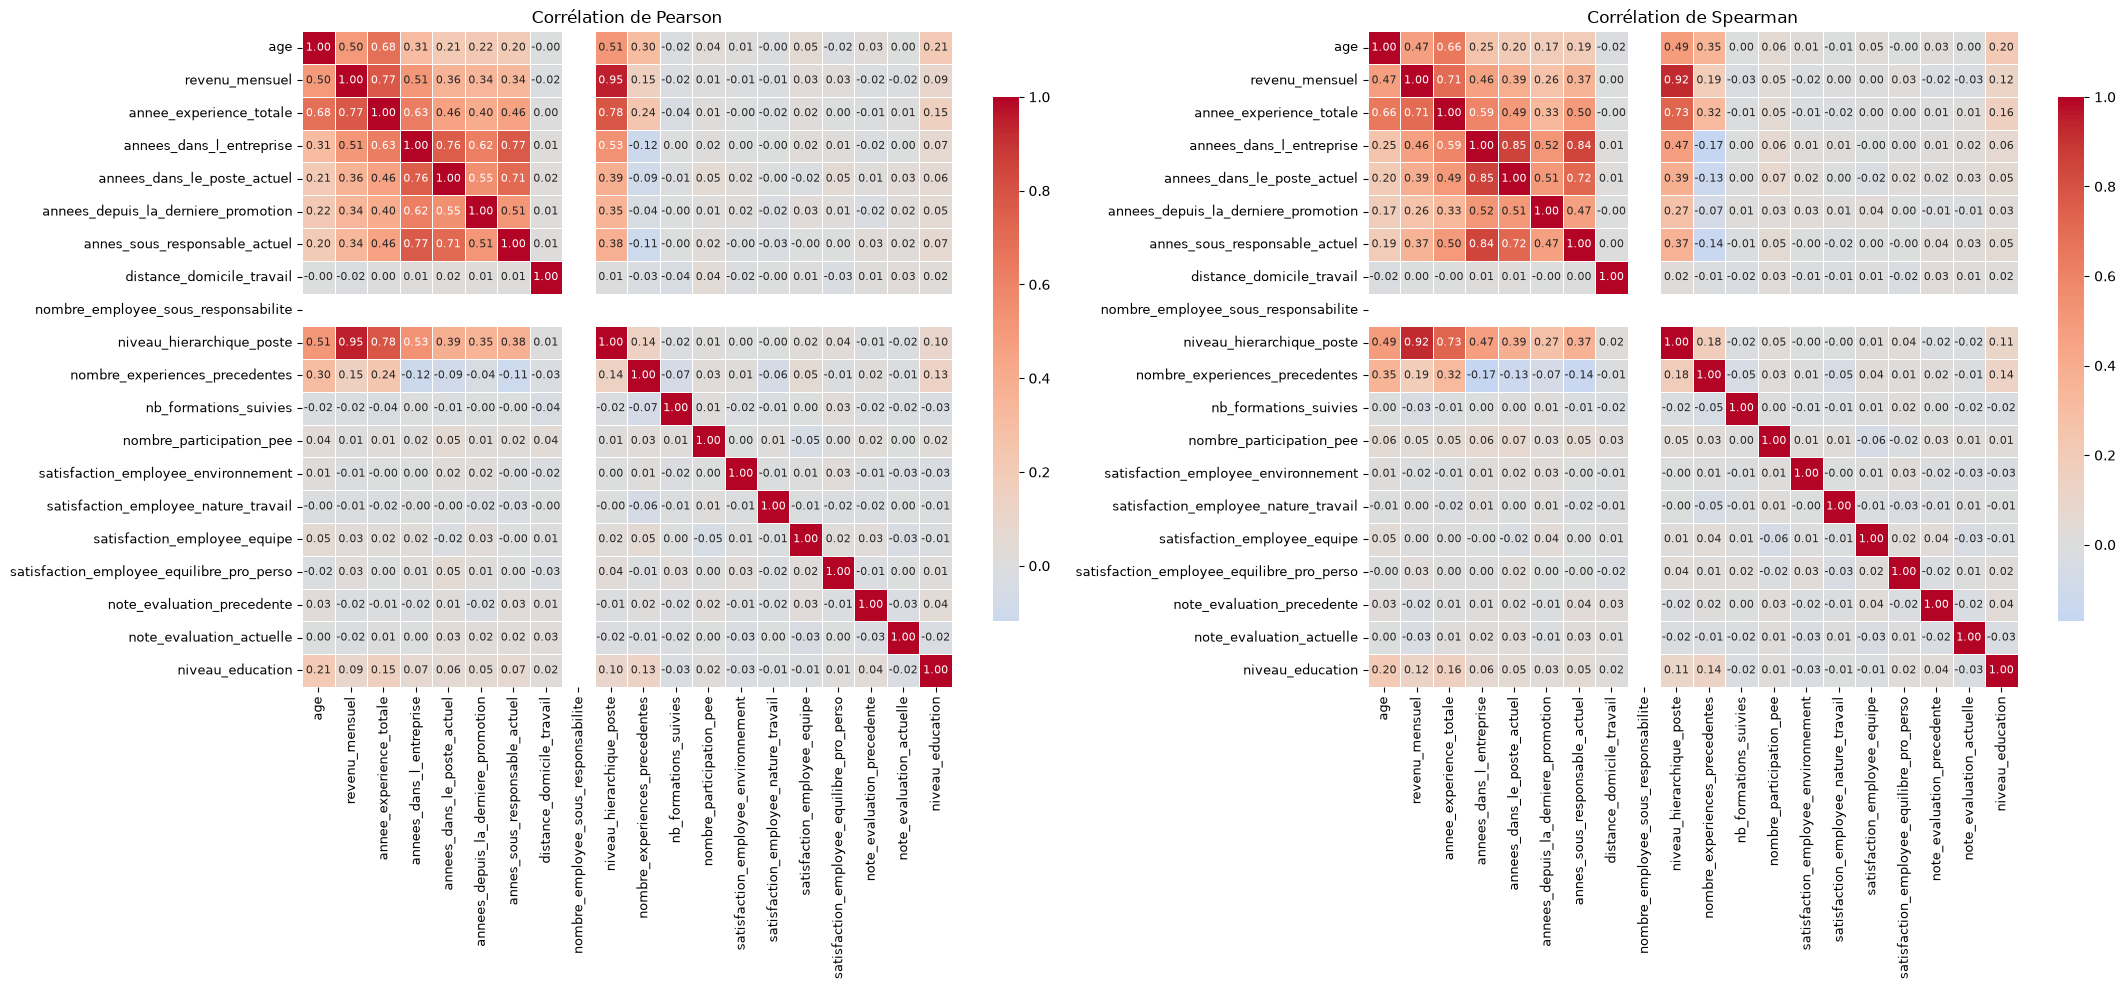

Paires de corrélation |r| >= 0.70 — Pearson :
revenu_mensuel <-> annee_experience_totale : 0.77
revenu_mensuel <-> niveau_hierarchique_poste : 0.95
annee_experience_totale <-> niveau_hierarchique_poste : 0.78
annees_dans_l_entreprise <-> annees_dans_le_poste_actuel : 0.76
annees_dans_l_entreprise <-> annes_sous_responsable_actuel : 0.77
annees_dans_le_poste_actuel <-> annes_sous_responsable_actuel : 0.71

Paires de corrélation |r| >= 0.70 — Spearman :
revenu_mensuel <-> annee_experience_totale : 0.71
revenu_mensuel <-> niveau_hierarchique_poste : 0.92
annee_experience_totale <-> niveau_hierarchique_poste : 0.73
annees_dans_l_entreprise <-> annees_dans_le_poste_actuel : 0.85
annees_dans_l_entreprise <-> annes_sous_responsable_actuel : 0.84
annees_dans_le_poste_actuel <-> annes_sous_responsable_actuel : 0.72


In [17]:


cols_pearson = [
    'age', 'revenu_mensuel', 'annee_experience_totale',
    'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
    'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel',
    'distance_domicile_travail', 'nombre_employee_sous_responsabilite',
    'niveau_hierarchique_poste', 'nombre_experiences_precedentes',
    'nb_formations_suivies', 'nombre_participation_pee'
]

cols_spearman = [
    'satisfaction_employee_environnement', 'satisfaction_employee_nature_travail',
    'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso',
    'note_evaluation_precedente', 'note_evaluation_actuelle', 'niveau_education'
]

all_cols = cols_pearson + cols_spearman

corr_pearson = DataFrameRH[all_cols].corr(method='pearson')
corr_spearman = DataFrameRH[all_cols].corr(method='spearman')

n = len(all_cols)

print('Paires chiffrées Pearson :')
for i in range(n):
    for j in range(i + 1, n):
        print(f'{all_cols[i]} <-> {all_cols[j]} : {corr_pearson.iloc[i, j]:.2f}')

print()
print('Paires chiffrées Spearman :')
for i in range(n):
    for j in range(i + 1, n):
        print(f'{all_cols[i]} <-> {all_cols[j]} : {corr_spearman.iloc[i, j]:.2f}')

annot_size = max(6, 160 / n)
tick_size = max(7, 180 / n)
title_size = max(12, 200 / n)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

sns.heatmap(
    corr_pearson,
    ax=axes[0],
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': annot_size},
    cbar_kws={'shrink': 0.8},
    linewidths=0.4,
    linecolor='white'
)
axes[0].set_title('Corrélation de Pearson', fontsize=title_size)
axes[0].tick_params(axis='both', labelsize=tick_size)

sns.heatmap(
    corr_spearman,
    ax=axes[1],
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': annot_size},
    cbar_kws={'shrink': 0.8},
    linewidths=0.4,
    linecolor='white'
)
axes[1].set_title('Corrélation de Spearman', fontsize=title_size)
axes[1].tick_params(axis='both', labelsize=tick_size)

plt.tight_layout()
plt.show()



print('Paires de corrélation |r| >= 0.70 — Pearson :')
for i in range(n):
    for j in range(i + 1, n):
        value = corr_pearson.iloc[i, j]
        if abs(value) >= 0.70:
            print(f'{all_cols[i]} <-> {all_cols[j]} : {value:.2f}')

print()
print('Paires de corrélation |r| >= 0.70 — Spearman :')
for i in range(n):
    for j in range(i + 1, n):
        value = corr_spearman.iloc[i, j]
        if abs(value) >= 0.70:
            print(f'{all_cols[i]} <-> {all_cols[j]} : {value:.2f}')

Commentaires résultats :

- nombre_employee_sous_responsabilite : NaN partout
- Six paires dépassent 0,70 dans les deux méthodes :

revenu_mensuel <-> niveau_hierarchique_poste : 0,95 (Pearson) / 0,92 (Spearman)
annee_experience_totale <-> niveau_hierarchique_poste : 0,78 / 0,73
revenu_mensuel <-> annee_experience_totale : 0,77 / 0,71
annees_dans_l_entreprise <-> annes_sous_responsable_actuel : 0,77 / 0,84
annees_dans_l_entreprise <-> annees_dans_le_poste_actuel : 0,76 / 0,85
annees_dans_le_poste_actuel <-> annes_sous_responsable_actuel : 0,71 / 0,72

-  revenu_mensuel, niveau_hierarchique_poste et annee_experience_totale mesurent quasiment la même chose sous trois angles différents — l'ancienneté/statut professionnel.


- même chose pour le trio annees_dans_l_entreprise, annees_dans_le_poste_actuel, annes_sous_responsable_actuel



### Corrélation et distribution

In [18]:
#Suppression des vars

DataFrameRH = DataFrameRH.drop(
    columns=['annes_sous_responsable_actuel', 'annees_dans_le_poste_actuel'],
    errors='ignore'
)



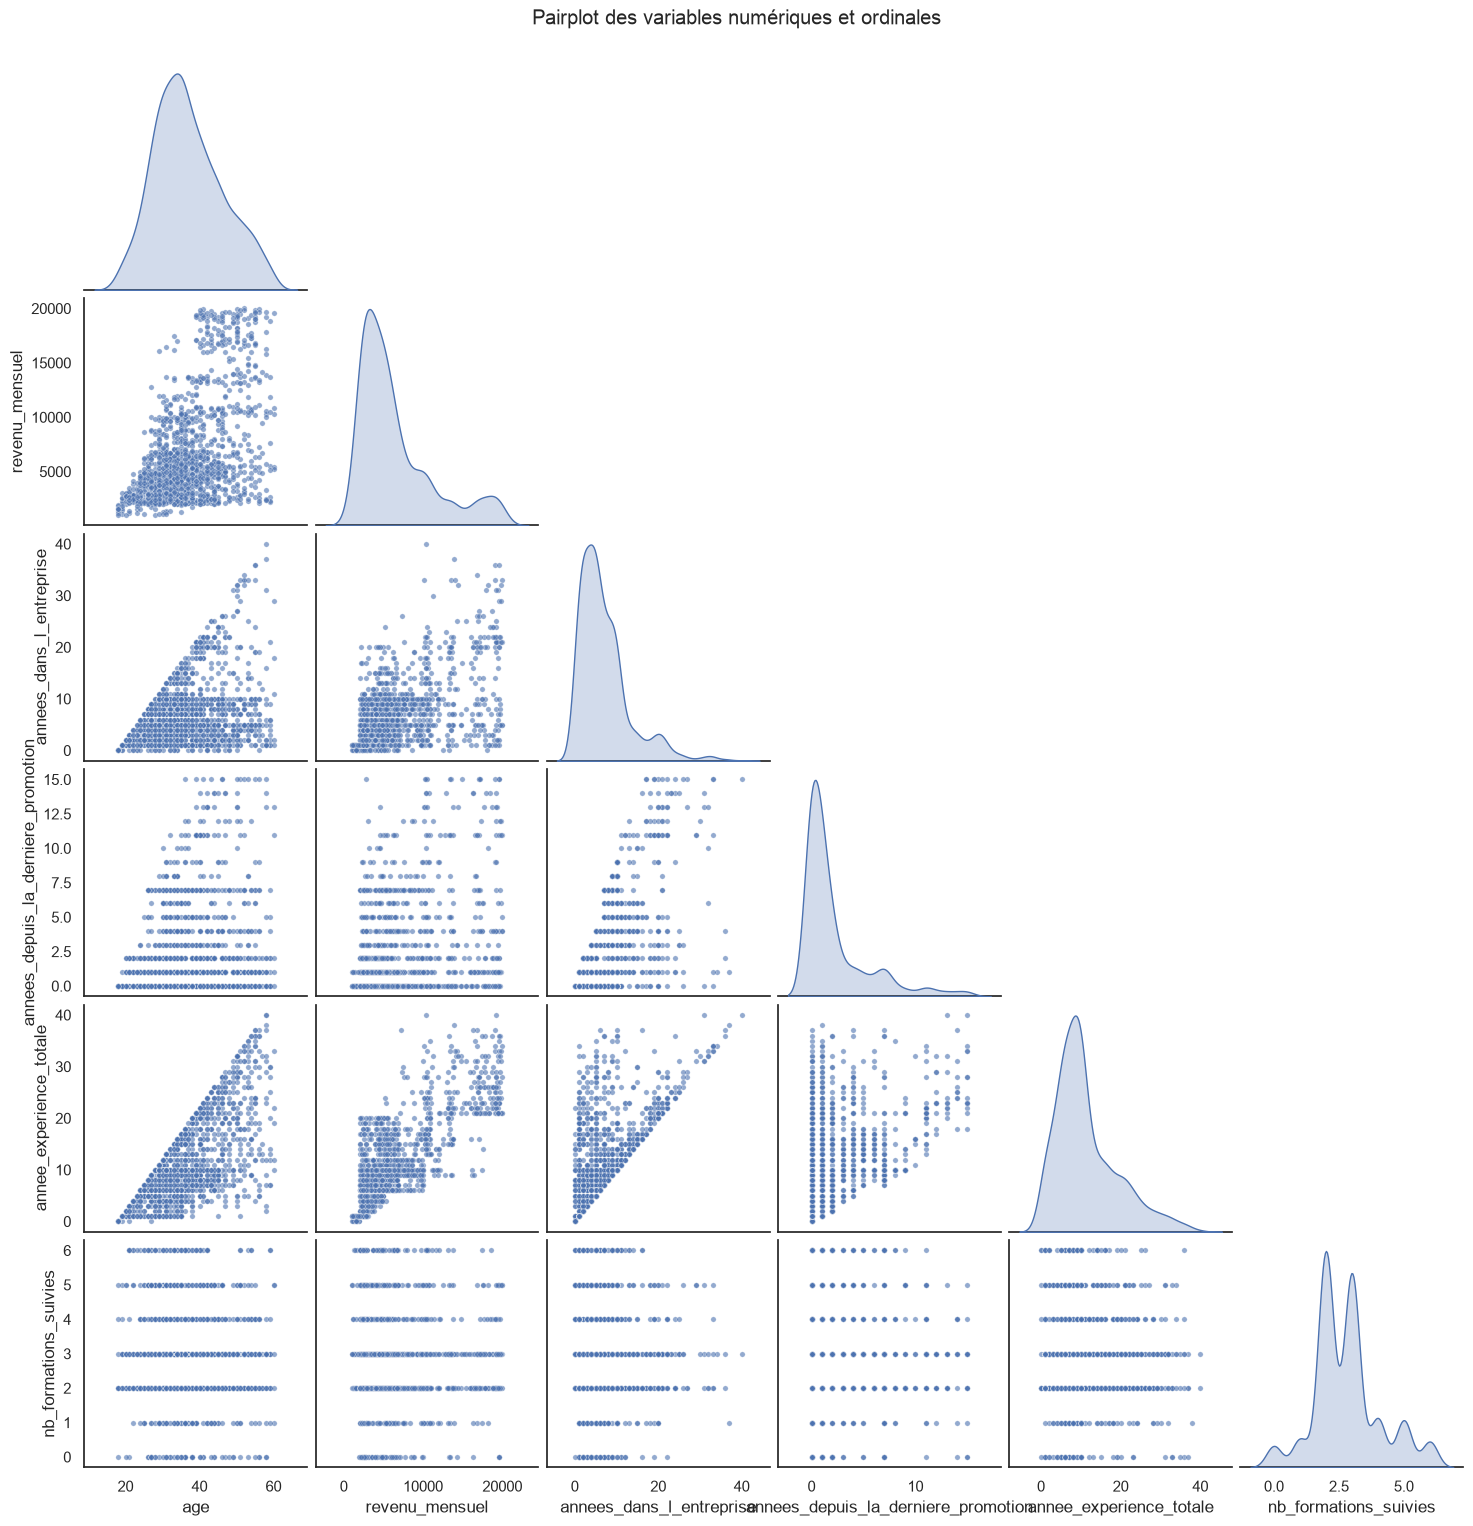

In [19]:
pairplot_cols = [
    'age',
    'revenu_mensuel',
    'annees_dans_l_entreprise',
    'annees_depuis_la_derniere_promotion',
    'annee_experience_totale',
    'nb_formations_suivies',
]

pair_df = DataFrameRH[pairplot_cols].apply(pd.to_numeric, errors='coerce')

sns.set_theme(style='white')

sns.pairplot(
    pair_df.dropna(),
    corner=True,
    diag_kind='kde',
    plot_kws={'s': 15, 'alpha': 0.6}
).fig.suptitle('Pairplot des variables numériques et ordinales', y=1.02)

plt.show()
















Commentaires :
- le revenu mensuel est corrrélé en 0,71 avec le total d'années d'expérience.  la relation existe mais n'est pas parfaitement linéaire, la dispersion augmente avec l'expérience

- revenu_mensuel : distribution bimodale nette sur la diagonale — un pic principal vers 3000-5000€, un second pic secondaire vers 12000-15000€. 


- age : distribution asymétrique à droite, quasi normale tronquée — cohérent avec une population salariale (peu de très jeunes, peu de très âgés, la masse est entre 25 et 45 ans).


- annees_dans_l_entreprise, annees_depuis_la_derniere_promotion, annee_experience_totale : toutes fortement asymétriques à droite : c'est une distribution structurellement exponentielle-décroissante : la majorité des employés sont récents/juniors, une minorité décroissante est ancienne/senior. C'est la distribution normale d'une pyramide des âges d'entreprise, pas une anomalie statistique.

- nb_formations_suivies : distribution multimodale avec pics discrets à 0, 2-3, et 5 — variable clairement discrète et bornée (0 à 6), pas continue. Aucune relation visible avec les autres variables.


- annees_depuis_la_derniere_promotion : forte concentration à 0 — une majorité de la population a été promue très récemment (cette année) ou jamais.

### transformation, Encodage, gestion des var pour la modélisation

In [20]:
# Colonnes qualitatives : dtype object + variables numériques à faible nombre de modalités
qualitative_cols = [
    col for col in DataFrameRH.columns
    if DataFrameRH[col].dtype == 'object'
    or (pd.api.types.is_numeric_dtype(DataFrameRH[col]) and DataFrameRH[col].nunique(dropna=False) <= 10)
]

print('Variables qualitatives détectées :')
print(qualitative_cols)
print()

for col in qualitative_cols:
    vc = DataFrameRH[col].value_counts(dropna=False)
    print(f'--- {col} : {vc.size} modalités uniques ---')
    print(vc.to_string())
    print()

Variables qualitatives détectées :
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'nombre_experiences_precedentes', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'niveau_education']

--- satisfaction_employee_environnement : 4 modalités uniques ---
satisfaction_employee_environnement
3    453
4    446
2    287
1    284

--- note_evaluation_precedente : 4 modalités uniques ---
note_evaluation_precedente
3    868
2    375
4    144
1     83

--- niveau_hierarchique_poste : 5 modalités uniques ---
niveau_hierarchique_poste
1    543
2    534
3    218
4    106
5     69

--- satisfaction_employee_nature_travail : 4 modalités uniques ---
satisfaction_employee_nature_travail
4    459
3    442
1    289
2    280

--- satisfaction_employee_equipe : 4 modalité

In [21]:

bins_exp = [-1, 0, 2, 5, 9]
labels_exp = ['Aucune_experience', 'Junior', 'Confirme', 'Senior']

DataFrameRH['experience_classe'] = pd.cut(
    DataFrameRH['nombre_experiences_precedentes'],
    bins=bins_exp,
    labels=labels_exp
)

# --- 2. augementation_salaire_precedente : nettoyage + bins ---
DataFrameRH['augementation_salaire_precedente'] = (
    DataFrameRH['augementation_salaire_precedente']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
    .astype(float)
)

# Bornes métier : faible / modérée / forte / exceptionnelle augmentation
bins_aug = [10, 14, 18, 22, 25]
labels_aug = ['Faible_10-14%', 'Moderee_15-18%', 'Forte_19-22%', 'Exceptionnelle_23-25%']

DataFrameRH['augmentation_classe'] = pd.cut(
    DataFrameRH['augementation_salaire_precedente'],
    bins=bins_aug,
    labels=labels_aug
)

# --- 3. Vérification : distribution des classes créées ---
print(DataFrameRH['experience_classe'].value_counts())
print(DataFrameRH['augmentation_classe'].value_counts())

experience_classe
Junior               667
Confirme             361
Senior               245
Aucune_experience    197
Name: count, dtype: int64
augmentation_classe
Faible_10-14%            818
Moderee_15-18%           350
Forte_19-22%             235
Exceptionnelle_23-25%     67
Name: count, dtype: int64


In [22]:

enc = OneHotEncoder(sparse_output=False)

encoded = enc.fit_transform(DataFrameRH[['experience_classe', 'augmentation_classe']])
colonnes = enc.get_feature_names_out(['experience_classe', 'augmentation_classe'])

# Reconstruction propre en DataFrame, avec les bons noms de colonnes et le bon index
df_encoded = pd.DataFrame(encoded, columns=colonnes, index=DataFrameRH.index)

# Concaténation avec le dataframe original
DataFrameRH = pd.concat([DataFrameRH, df_encoded], axis=1)

In [23]:

##Nettoyage des colonnes originales après encodage et autre


cols_to_drop = ['augmentation_classe','experience_classe']


DataFrameRH = DataFrameRH.drop(columns=cols_to_drop)

In [24]:
DataFrameRH.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   satisfaction_employee_environnement        1470 non-null   int64  
 1   note_evaluation_precedente                 1470 non-null   int64  
 2   niveau_hierarchique_poste                  1470 non-null   int64  
 3   satisfaction_employee_nature_travail       1470 non-null   int64  
 4   satisfaction_employee_equipe               1470 non-null   int64  
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 6   note_evaluation_actuelle                   1470 non-null   int64  
 7   heure_supplementaires                      1470 non-null   str    
 8   augementation_salaire_precedente           1470 non-null   float64
 9   age                                        1470 non-null   int64  
 10  genre                              

In [25]:
# Distribution de la variable cible — nécessaire pour choisir classification vs régression ordinale
print(DataFrameRH['satisfaction_employee_environnement'].value_counts())
print()

# Modalités de toutes les colonnes object restantes, pour trancher ordinal vs nominal
colonnes_object = DataFrameRH.select_dtypes(include='object').columns

for col in colonnes_object:
    print(f"--- {col} : {DataFrameRH[col].nunique()} modalités ---")
    print(DataFrameRH[col].value_counts())
    print()

satisfaction_employee_environnement
3    453
4    446
2    287
1    284
Name: count, dtype: int64

--- heure_supplementaires : 2 modalités ---
heure_supplementaires
Non    1054
Oui     416
Name: count, dtype: int64

--- genre : 2 modalités ---
genre
M    882
F    588
Name: count, dtype: int64

--- statut_marital : 3 modalités ---
statut_marital
Marié(e)       673
Célibataire    470
Divorcé(e)     327
Name: count, dtype: int64

--- departement : 3 modalités ---
departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

--- poste : 9 modalités ---
poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64

--- a_quitte_l_entreprise : 2 modalités ---
a_quitte_l_entreprise
Non    12

/var/folders/76/v3gkc48n6_z8w_gst8yvldm40000gn/T/ipykernel_12131/3205793057.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_object = DataFrameRH.select_dtypes(include='object').columns


In [26]:
#Correction des var ordinal stockées en texte
colonnes_ordinales_numeriques = [
    'note_evaluation_precedente',
    'niveau_hierarchique_poste',
    'satisfaction_employee_nature_travail',
    'satisfaction_employee_equipe',
    'satisfaction_employee_equilibre_pro_perso',
    'note_evaluation_actuelle',
    'nombre_participation_pee',
    'niveau_education'
]

DataFrameRH[colonnes_ordinales_numeriques] = DataFrameRH[colonnes_ordinales_numeriques].astype(int)

In [27]:
#Traitement en 0 et 1 de déplacement


ordre_deplacement = {'Aucun': 0, 'Occasionnel': 1, 'Frequent': 2}

DataFrameRH['frequence_deplacement'] = DataFrameRH['frequence_deplacement'].map(ordre_deplacement)

In [28]:
#Traitemetn en binaire de genre et de heure supplémentaire


DataFrameRH['heure_supplementaires'] = DataFrameRH['heure_supplementaires'].map({'Non': 0, 'Oui': 1})
DataFrameRH['a_quitte_l_entreprise'] = DataFrameRH['a_quitte_l_entreprise'].map({'Non': 0, 'Oui': 1})
DataFrameRH['genre'] = DataFrameRH['genre'].map({'F': 0, 'M': 1})

In [29]:
#Traitement des dernières variables nominales pures

colonnes_nominales = ['statut_marital', 'departement', 'poste', 'domaine_etude']

DataFrameRH = pd.get_dummies(DataFrameRH, columns=colonnes_nominales, drop_first=True)

In [30]:
#Transformation de la variable cible

DataFrameRH['satisfaction_employee_environnement'] = DataFrameRH['satisfaction_employee_environnement'].astype(int)

In [31]:
DataFrameRH.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 48 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   satisfaction_employee_environnement        1470 non-null   int64  
 1   note_evaluation_precedente                 1470 non-null   int64  
 2   niveau_hierarchique_poste                  1470 non-null   int64  
 3   satisfaction_employee_nature_travail       1470 non-null   int64  
 4   satisfaction_employee_equipe               1470 non-null   int64  
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 6   note_evaluation_actuelle                   1470 non-null   int64  
 7   heure_supplementaires                      1470 non-null   int64  
 8   augementation_salaire_precedente           1470 non-null   float64
 9   age                                        1470 non-null   int64  
 10  genre                              

### Partitionnement X et y

In [32]:
y = DataFrameRH['satisfaction_employee_environnement']   # Series 1D : la cible
X = DataFrameRH.drop(columns='satisfaction_employee_environnement')  # DataFrame : tout le reste

# Vérification rapide de cohérence dimensionnelle
print(X.shape)   
print(y.shape)   

(1470, 47)
(1470,)


In [33]:
sauvegarder_session(2)

Session de l'étape 2 enregistrée
Fichier : /Users/thibaultdautheville/Downloads/Projet 4/Script_intermediaire/outputs/session_etape2.pkl
Objets sauvegardés : 85
Objets ignorés : 0


PosixPath('/Users/thibaultdautheville/Downloads/Projet 4/Script_intermediaire/outputs/session_etape2.pkl')